# K-Means Clustering on Fashion MNIST Dataset

In this project, I applied **K-Means Clustering** to perform **unsupervised learning** on fashion images. The goal is to group similar clothing items together without using any labels.

---

## Dataset Overview

The dataset used is the [Fashion MNIST dataset](https://www.kaggle.com/datasets/zalando-research/fashionmnist?select=fashion-mnist_train.csv), provided by Zalando Research. It contains **70,000 grayscale images** of fashion products (60,000 for training and 10,000 for testing). Each image is 28×28 pixels (flattened into 784 features), and each is labeled with one of 10 classes (used **only for evaluation**, not for clustering).

- **Total Examples**: 70,000  
- **Image Size**: 28 × 28 pixels → 784 pixels in total  
- **Labels (not used in training)**:  
  - 0: T-shirt/top  
  - 1: Trouser  
  - 2: Pullover  
  - 3: Dress  
  - 4: Coat  
  - 5: Sandal  
  - 6: Shirt  
  - 7: Sneaker  
  - 8: Bag  
  - 9: Ankle boot  

---

Even though true labels are available, they were not used during training. This makes the task a true **unsupervised learning** problem. The project showcases how K-Means can reveal meaningful patterns in image data without supervision.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving fashion-mnist_test.csv to fashion-mnist_test.csv
Saving fashion-mnist_train.csv to fashion-mnist_train.csv


In [3]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Reading the img dataset
df = pd.read_csv('fashion-mnist_train.csv')

df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Each row represents a grayscale image in the Fashion MNIST dataset, with the first column as the label (0–9) and the remaining 784 columns representing pixel intensity values from the 28×28 image.

In [6]:
df.shape

(60000, 785)

The shape (60000, 785) means the dataset contains 60,000 images, each represented by 785 values: 1 label column and 784 pixel values (28×28 grayscale image flattened into a vector).

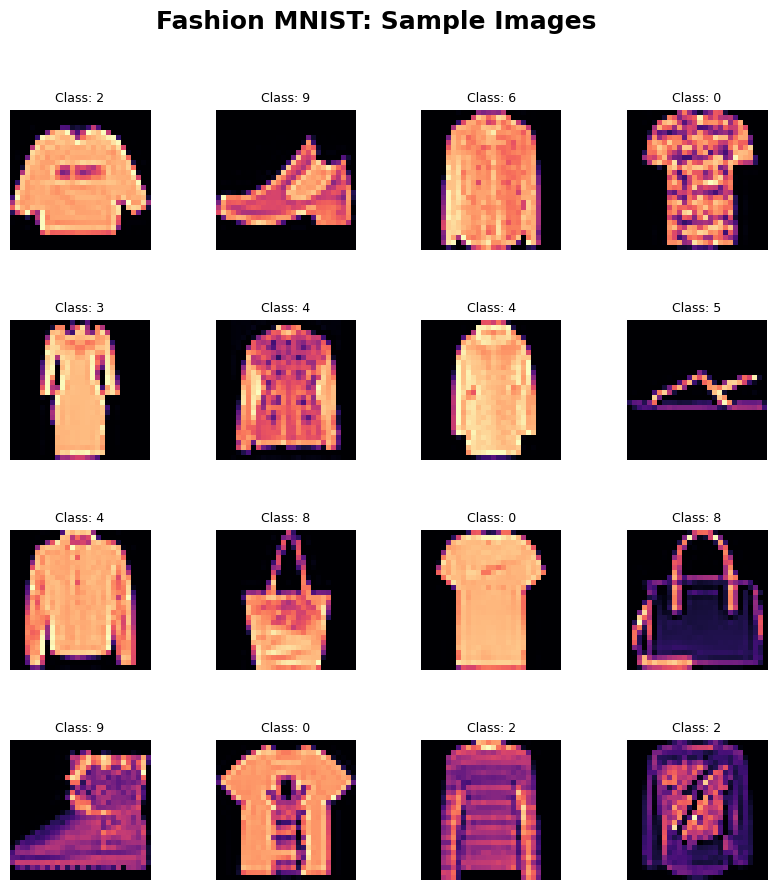

In [7]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
fig.suptitle("Fashion MNIST: Sample Images", fontsize=18, fontweight='bold')

for idx in range(16):
    row, col = divmod(idx, 4)
    image = df.iloc[idx, 1:].values.reshape(28, 28)
    label = df.iloc[idx, 0]

    axs[row, col].imshow(image, cmap='magma')
    axs[row, col].set_title(f"Class: {label}", fontsize=9)
    axs[row, col].axis("off")

plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


This image shows a 4×4 grid of sample items from the Fashion MNIST dataset, each labeled with its corresponding class (e.g., T-shirt, sneaker, bag).

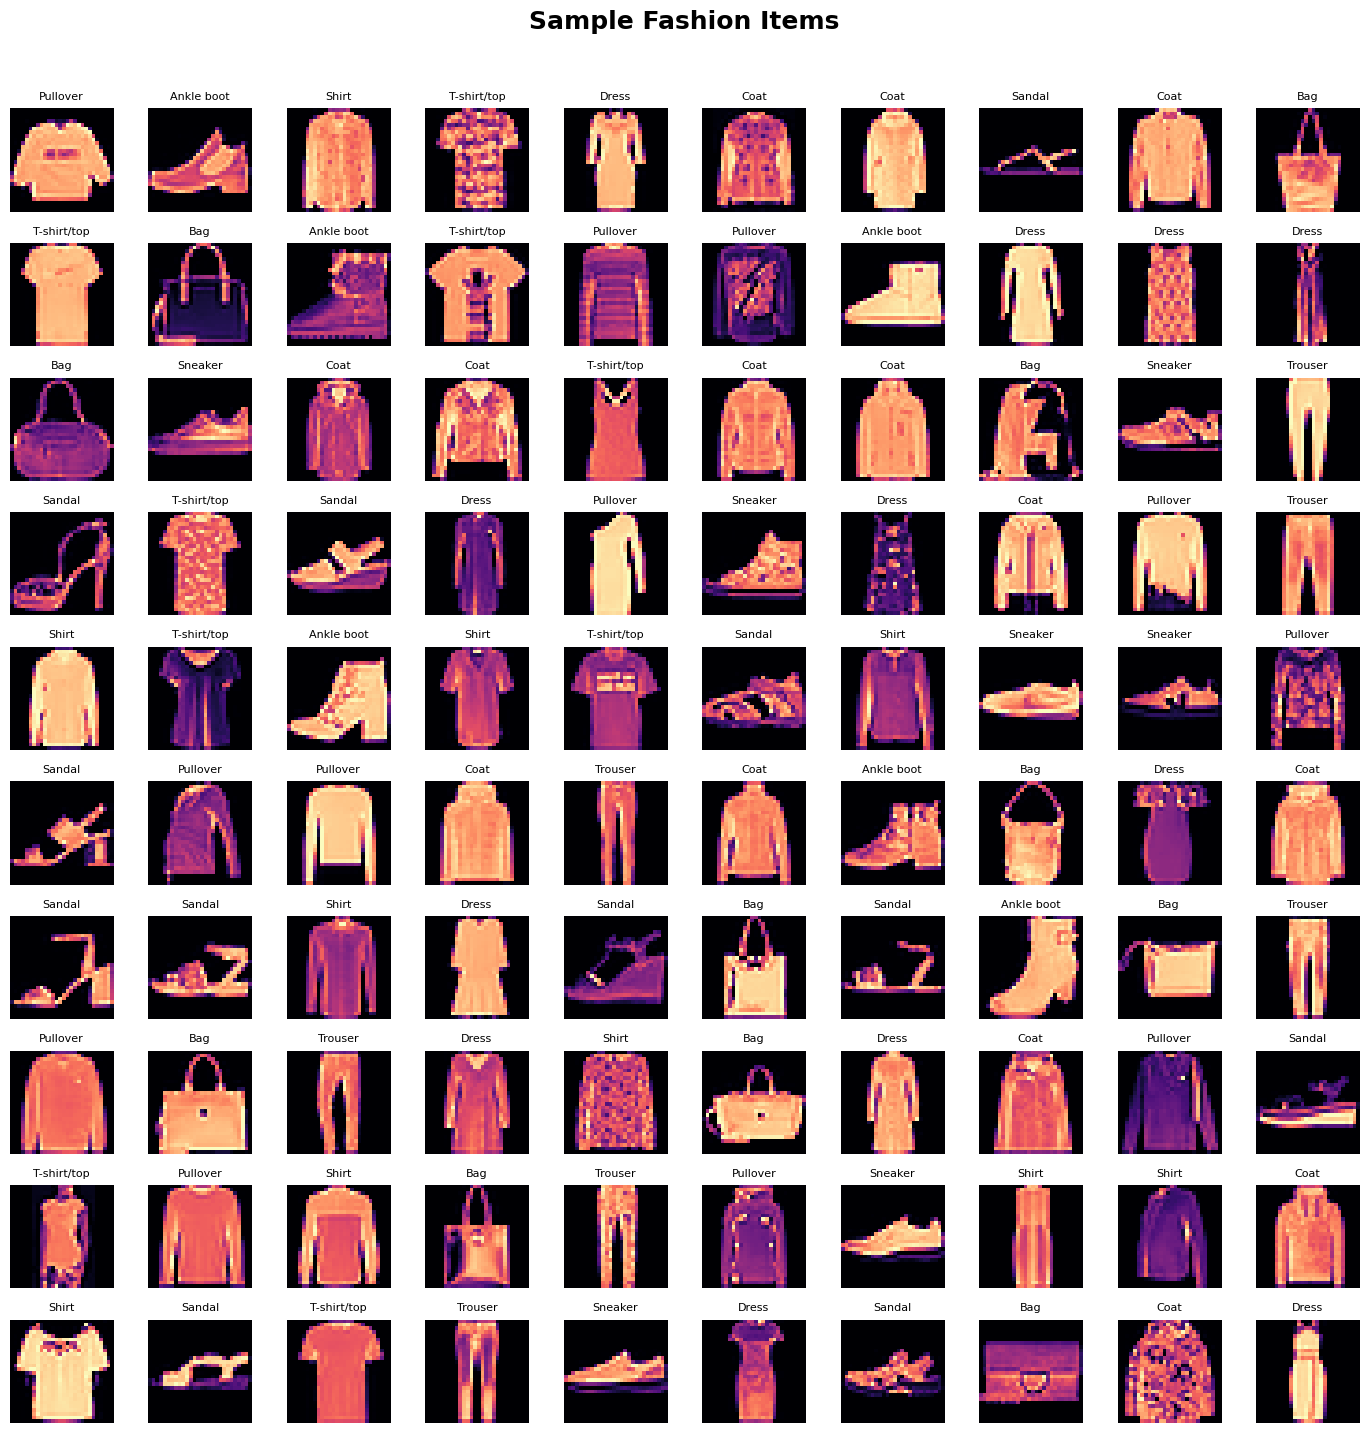

In [10]:
def show_fashion_samples(x_data, y_data, class_names, cmap='magma'):
    fig, axes = plt.subplots(10, 10, figsize=(14, 14))
    fig.suptitle("Sample Fashion Items", fontsize=18, weight='bold', y=1.02)

    for i, ax in enumerate(axes.flat):
        img = x_data[i].reshape(28, 28)
        label = int(y_data[i])
        ax.imshow(img, cmap=cmap)
        ax.set_title(class_names[label], fontsize=8)
        ax.axis('off')


    plt.tight_layout()
    plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_train = df.iloc[:, 0].values
x_train = df.iloc[:, 1:].values.reshape(-1, 28, 28)

show_fashion_samples(x_train, y_train, class_names)

This grid displays a diverse set of 100 sample images from the Fashion MNIST dataset, illustrating all 10 clothing categories with their predicted labels.

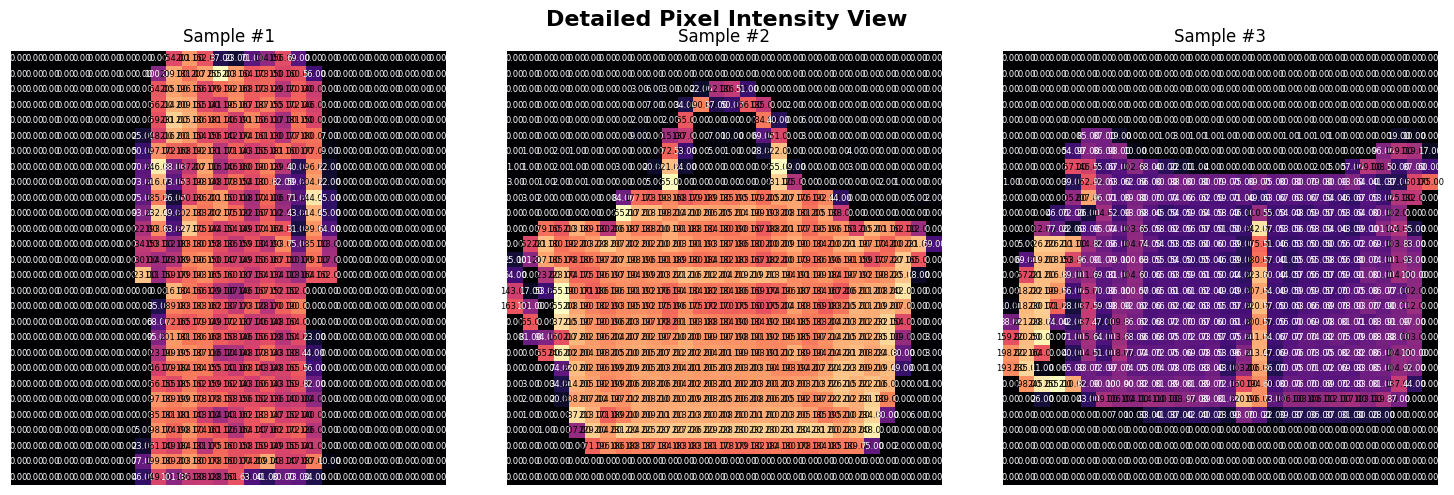

In [11]:
def visualize_sample_pixels(images, num_samples=3, cmap='magma'):
    if isinstance(images, np.ndarray):
        indices = np.random.choice(images.shape[0], num_samples, replace=False)
        selected = images[indices]
    else:
        selected = images[:num_samples]

    fig, axs = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    fig.suptitle('Detailed Pixel Intensity View', fontsize=16, weight='bold')

    for idx, ax in enumerate(axs):
        img = selected[idx]
        ax.imshow(img, cmap=cmap)
        ax.set_title(f'Sample #{idx + 1}', fontsize=12)
        ax.axis('off')

        rows, cols = img.shape
        threshold = img.max() / 2.5

        for x in range(rows):
            for y in range(cols):
                val = round(img[x, y], 2)
                ax.text(y, x, f'{val:.2f}',
                        ha='center', va='center',
                        color='white' if img[x, y] < threshold else 'black',
                        fontsize=6)

    plt.tight_layout()
    plt.show()

visualize_sample_pixels(x_train, num_samples=3)


This visualization shows three sample Fashion MNIST images with annotated pixel intensity values, providing a detailed view of how brightness levels vary across different regions of each clothing item.

<ipython-input-13-2ee96e64a81c>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(range(len(counts))), y=counts.values, palette='pastel')


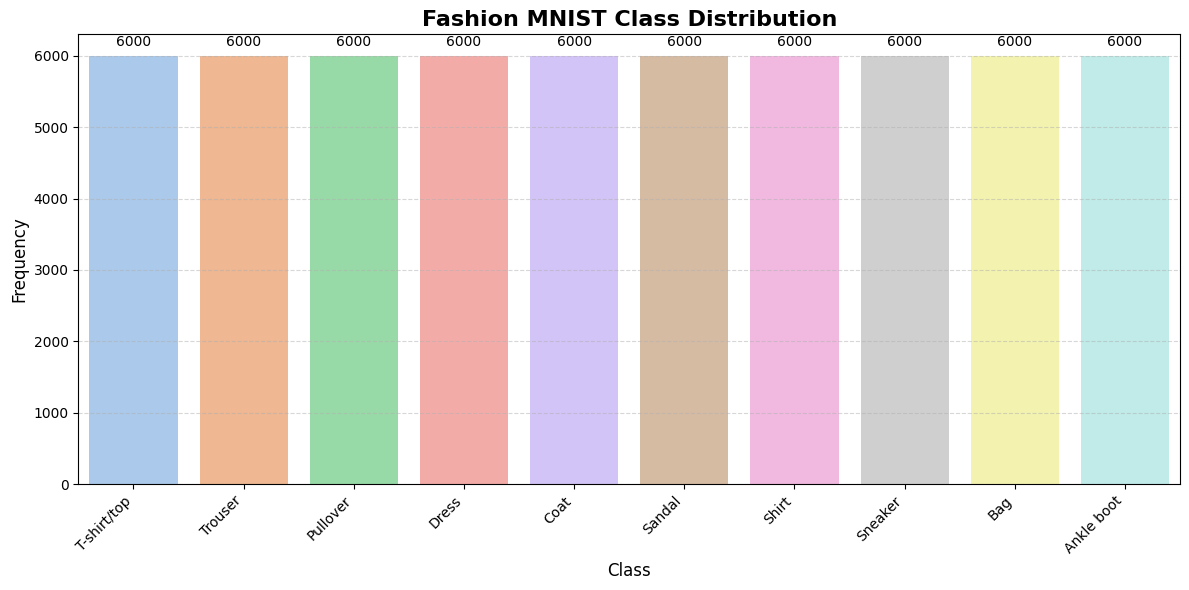

In [13]:
import seaborn as sns

def plot_class_distribution(y, class_names):
    counts = pd.Series(y).value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    bars = sns.barplot(x=list(range(len(counts))), y=counts.values, palette='pastel')

    plt.title("Fashion MNIST Class Distribution", fontsize=16, weight='bold')
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha='right')

    for idx, value in enumerate(counts.values):
        plt.text(idx, value + 100, str(value), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y = df.iloc[:, 0]

plot_class_distribution(y, class_names)


This bar chart shows that the Fashion MNIST dataset is perfectly balanced, with exactly 6,000 samples in each of the 10 clothing categories.

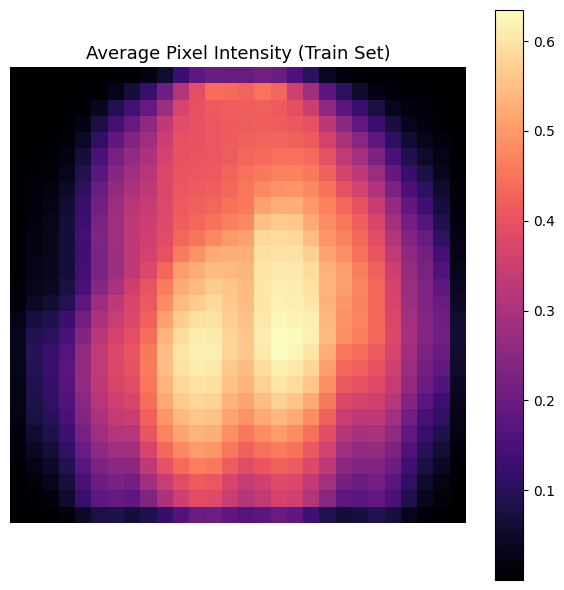

In [14]:
def plot_average_pixel_intensity(x_train):
    pixel_means = x_train.reshape(-1, 28*28).mean(axis=0)

    plt.figure(figsize=(6, 6))
    plt.imshow(pixel_means.reshape(28, 28), cmap='magma')
    plt.title('Average Pixel Intensity (Train Set)', fontsize=13)
    plt.colorbar()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

x_train = df.iloc[:, 1:].values.reshape(-1, 28, 28) / 255.0
plot_average_pixel_intensity(x_train)

This heatmap shows the average pixel intensity across all training images in the Fashion MNIST dataset, revealing that most items are centered and vertically elongated.

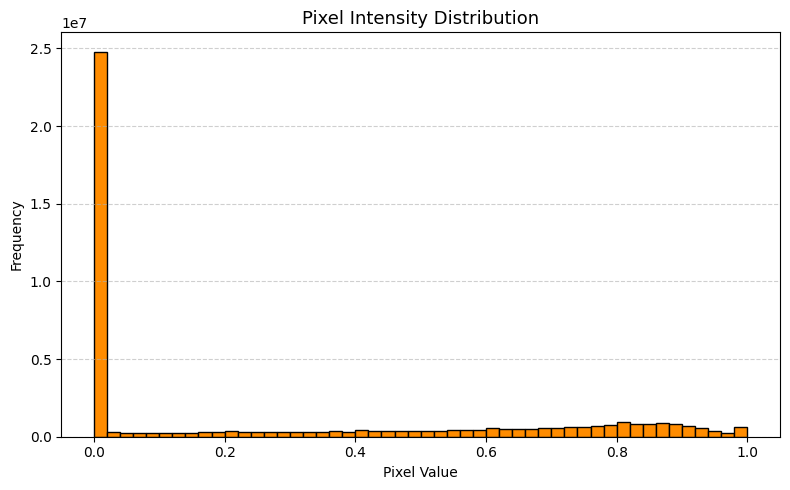

In [15]:
def plot_pixel_intensity_histogram(x_train):
    plt.figure(figsize=(8, 5))
    plt.hist(x_train.flatten(), bins=50, color='darkorange', edgecolor='black')
    plt.title('Pixel Intensity Distribution', fontsize=13)
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_pixel_intensity_histogram(x_train)

This histogram shows that a large number of pixels in the Fashion MNIST images have intensity close to 0 (i.e., black background), while a smaller portion spans the full intensity range—highlighting the contrast between background and foreground clothing patterns.

In [16]:
# Scaling
# Before training the model, feature values are manually scaled to the [0, 1] range.
# This ensures that all input features contribute equally to the learning process,
# preventing features with larger ranges from dominating the model and improving both convergence speed and accuracy.
# Read train and test sets separately

df_train = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')

X_full = df_train.iloc[:, 1:].values
y_full = df_train.iloc[:, 0].values

x_train, x_val = X_full[:50000], X_full[50000:]
y_train, y_val = y_full[:50000], y_full[50000:]

x_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

# Normalize pixel values to [0, 1]
x_train = np.divide(x_train, 255.0).astype(np.float32)
x_val = np.divide(x_val, 255.0).astype(np.float32)
x_test = np.divide(x_test, 255.0).astype(np.float32)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (50000, 784)
Validation: (10000, 784)
Test: (10000, 784)


In [17]:
#reshape

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

print(f"Train shape: {x_train.shape}")
print(f"Validation shape: {x_val.shape}")
print(f"Test shape: {x_test.shape}")

Train shape: (50000, 784)
Validation shape: (10000, 784)
Test shape: (10000, 784)


# Model Building

## Model Logic
The K-Means algorithm partitions data into k clusters by minimizing within-cluster variance. The core steps are:

Initialize k centroids randomly.

Assignment step: Each data point is assigned to its nearest centroid (based on Euclidean distance).

Update step: Centroids are recomputed as the mean of the points in each cluster.

Repeat steps 2–3 until convergence (centroids don't move significantly or max iterations reached).

Mathematically, the objective is to minimize:

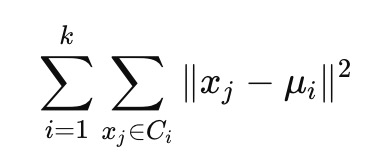

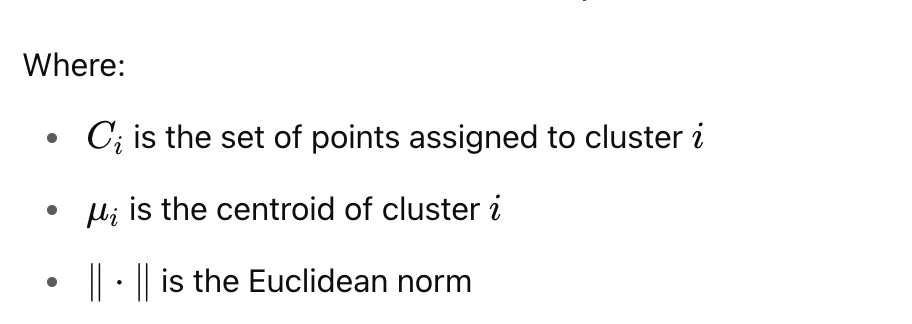

## Why This Model?
Unsupervised Learning Fit

Interpretability: Each cluster center can be visualized as an “average image,” which helps understand what each group represents.

## Objective
The goal is to group similar clothing items based solely on pixel-level features—without relying on any label.

In [18]:
class MyKMeans:
    def __init__(self, k=10, max_iter=100, tol=1e-4):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[random_idx]

        for i in range(self.max_iter):
            # Step 1: Assign to closest centroid
            distances = np.linalg.norm(X[:, None] - self.centroids, axis=2)
            self.labels_ = np.argmin(distances, axis=1)

            # Step 2: Recalculate centroids
            new_centroids = np.array([X[self.labels_ == j].mean(axis=0) if np.any(self.labels_ == j) else self.centroids[j] for j in range(self.k)])
            shift = np.linalg.norm(self.centroids - new_centroids)

            if shift < self.tol:
                break
            self.centroids = new_centroids

    def predict(self, X):
        distances = np.linalg.norm(X[:, None] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

kmeans = MyKMeans(k=10)
kmeans.fit(x_train)
cluster_labels = kmeans.labels_

In [ ]:
# Model evaluation

In [19]:
# Adjusted Rand Index & Silhouette Scores

from sklearn.metrics import adjusted_rand_score, silhouette_score
train_preds = kmeans.predict(x_train)
val_preds = kmeans.predict(x_val)
test_preds = kmeans.predict(x_test)

ari_train = adjusted_rand_score(y_train, train_preds)
ari_val = adjusted_rand_score(y_val, val_preds)
ari_test = adjusted_rand_score(y_test, test_preds)

s_train = silhouette_score(x_train, train_preds)
s_val = silhouette_score(x_val, val_preds)
s_test = silhouette_score(x_test, test_preds)

print(f"Train ARI: {ari_train:.4f}, Silhouette: {s_train:.4f}")
print(f"Validation ARI: {ari_val:.4f}, Silhouette: {s_val:.4f}")
print(f"Test ARI: {ari_test:.4f}, Silhouette: {s_test:.4f}")


Train ARI: 0.3454, Silhouette: 0.1355
Validation ARI: 0.3462, Silhouette: 0.1344
Test ARI: 0.3495, Silhouette: 0.1364


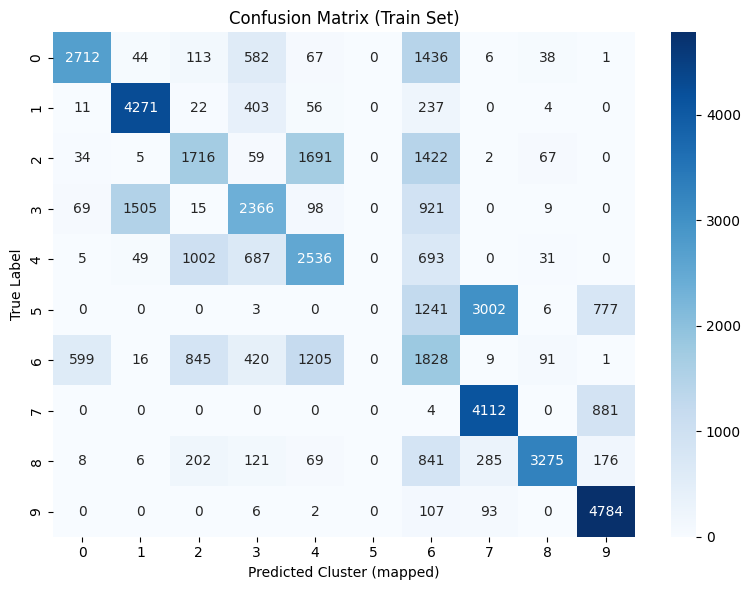

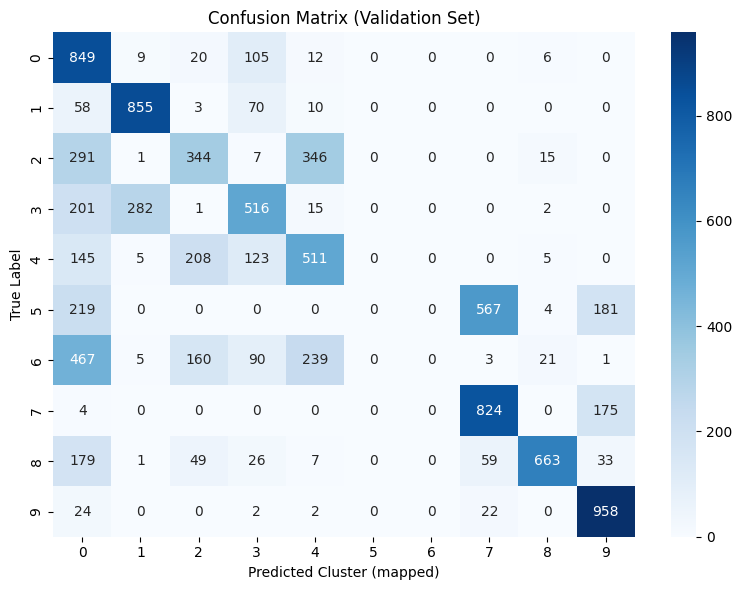

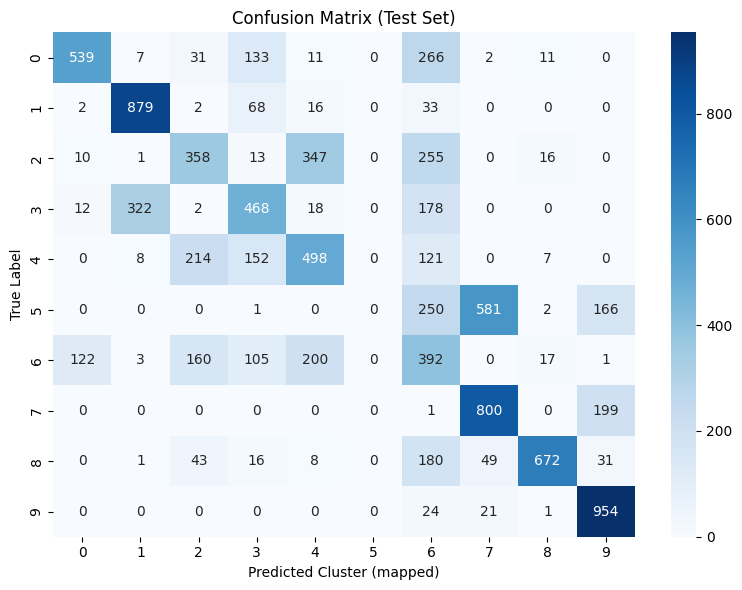

In [ ]:
# Confusion matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy.stats import mode

def plot_confusion_matrix(true_labels, cluster_labels, title):
    label_map = np.zeros_like(np.unique(cluster_labels))
    for i in range(len(label_map)):
        mask = (cluster_labels == i)
        if np.any(mask):
            label_map[i] = mode(true_labels[mask])[0]

    predicted_labels = label_map[cluster_labels]

    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix ({title})')
    plt.xlabel("Predicted Cluster (mapped)")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

train_preds = kmeans.predict(x_train)
val_preds = kmeans.predict(x_val)
test_preds = kmeans.predict(x_test)

plot_confusion_matrix(y_train, train_preds, "Train Set")
plot_confusion_matrix(y_val, val_preds, "Validation Set")
plot_confusion_matrix(y_test, test_preds, "Test Set")


# Model Performance Interpretation

**Adjusted Rand Index (ARI)：**

Train ARI: 0.3454, Validation ARI: 0.3462, Test ARI: 0.3495.

The ARI scores are consistent across all datasets, suggesting the model’s clustering is relatively stable and not overfitting. However, the moderate values reflect the inherent difficulty of clustering fashion items purely from pixel intensity without supervision.

**Silhouette Scores:**

Train: 0.1355,Validation: 0.1344, Test: 0.1364.
These low scores are expected in high-dimensional image data. They suggest some structure exists in the clusters, but the separation between clusters is weak—again reasonable, as pixel-based similarity might not always align with human-labeled fashion categories.

**Confusion matrix:**

Training Set:
Most clusters align well with dominant classes (e.g., cluster 1 with “Trouser”, cluster 7 with “Sneaker”).

Validation Set:
Similar confusion trends as training, with some minor instability in rare classes (e.g., Sandal or Bag) might due to smaller sample sizes.

Test Set:
Shows generalization capability, with similar patterns and error structure. This supports that the clustering is not random and does capture latent groupings.




# Model Comparison

For a detailed comparison of different unsupervised learning models we applied to the same dataset (e.g., K-Means Clustering, DBSCAN, Principal Component Analysis, and Image Compression with the Singular Value Decomposition (SVD)).

Please refer to my GitHub repository:
INDE577_Machine_Learning_2025_Rice_University/Model_comparison/Model_comparison_for_unsupervised_machine_learning.ipynb

Link for Model Comparison: [Model Comparison section on GitHub](https://github.com/AlexXu777/INDE577_Machine_Learning_2025_Rice_University/tree/main/Model_comparison)
